### Section B
-Q1)

In [208]:
import os
import librosa
import numpy as np
import pandas as pd
from scipy.io import wavfile
DATA_DIR = r'C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data (1)\data'
def compute_stats(file_path):
    y, sr = librosa.load(file_path, sr=16000) 
    amplitude_stats = {
        'mean_amp': np.mean(y),
        'median_amp': np.median(y),
        'std_amp': np.std(y),
        'min_amp': np.min(y),
        'max_amp': np.max(y),
        'duration_sec': librosa.get_duration(y=y, sr=sr)
    }
    return amplitude_stats
class_stats = {}
for class_folder in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_folder)
    if os.path.isdir(class_path):
        stats_list = []
        for wav_file in os.listdir(class_path):
            file_path = os.path.join(class_path, wav_file)
            if file_path.endswith('.wav'):
                stats = compute_stats(file_path)
                stats_list.append(stats)
        df_stats = pd.DataFrame(stats_list)
        class_stats[class_folder] = df_stats.describe()
for class_name, stats in class_stats.items():
    print(f"Class: {class_name}")
    print(stats)


Class: backward
           mean_amp   median_amp      std_amp      min_amp      max_amp  \
count  1.664000e+03  1664.000000  1664.000000  1664.000000  1664.000000   
mean   1.439029e-04     0.000158     0.076900    -0.553222     0.565784   
std    4.144932e-03     0.004223     0.044275     0.238404     0.237407   
min   -7.735643e-02    -0.076111     0.002323    -1.000000     0.001862   
25%   -5.131436e-05     0.000000     0.050403    -0.757568     0.392357   
50%   -2.651215e-07     0.000000     0.073207    -0.552963     0.580429   
75%    5.388022e-05     0.000031     0.094566    -0.385117     0.764656   
max    8.815067e-02     0.088165     0.665104    -0.011536     0.999969   

       duration_sec  
count   1664.000000  
mean       0.986390  
std        0.062522  
min        0.448000  
25%        1.000000  
50%        1.000000  
75%        1.000000  
max        1.000000  
Class: bed
           mean_amp   median_amp      std_amp      min_amp      max_amp  \
count  2.014000e+03  201

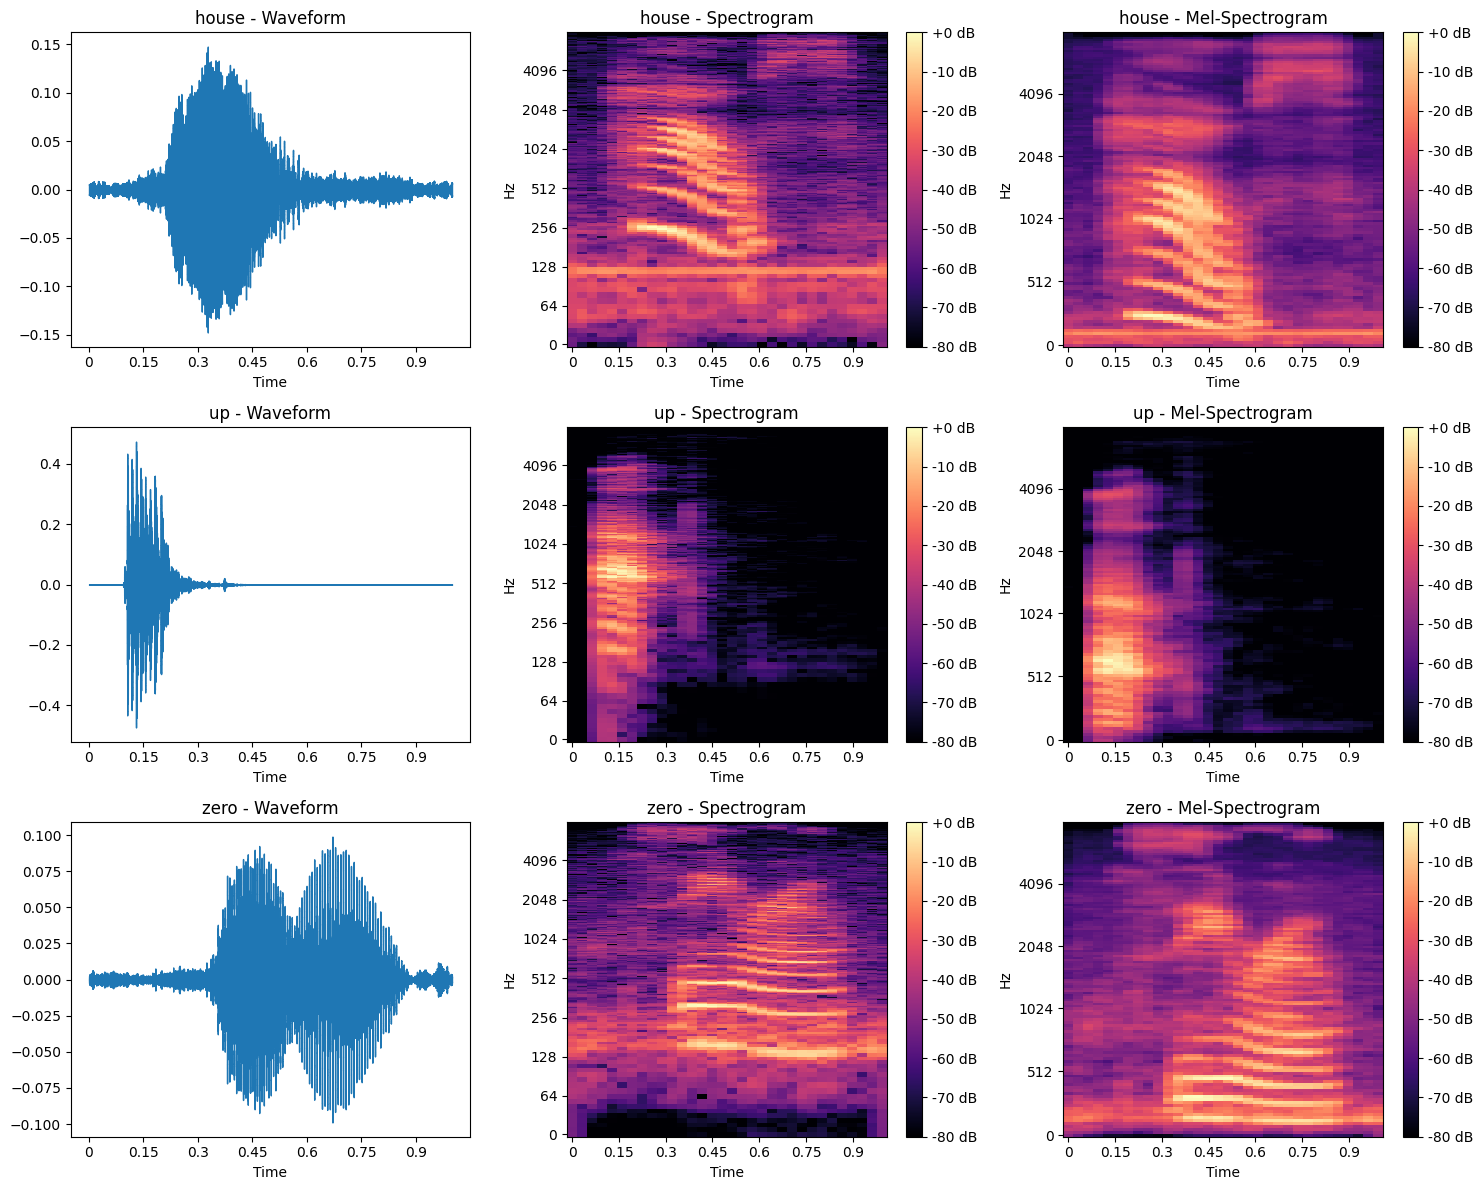

In [223]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

def plot_audio_features_multiple(files_with_classes, sr=16000):
    n_classes = len(files_with_classes)
    fig, axs = plt.subplots(n_classes, 3, figsize=(15, 4 * n_classes))
    
    for i, (file_path, class_name) in enumerate(files_with_classes):
        y, sr = librosa.load(file_path, sr=sr)
        
        librosa.display.waveshow(y, sr=sr, ax=axs[i, 0])
        axs[i, 0].set_title(f'{class_name} - Waveform')
        
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=axs[i, 1])
        axs[i, 1].set_title(f'{class_name} - Spectrogram')
        fig.colorbar(img, ax=axs[i, 1], format='%+2.0f dB')

        mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spect_dB = librosa.power_to_db(mel_spect, ref=np.max)
        img = librosa.display.specshow(mel_spect_dB, sr=sr, x_axis='time', y_axis='mel', ax=axs[i, 2])
        axs[i, 2].set_title(f'{class_name} - Mel-Spectrogram')
        fig.colorbar(img, ax=axs[i, 2], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()

def select_random_files(data_dir, n=3):
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    selected_files = []
    random_classes = random.sample(classes, n)
    
    for random_class in random_classes:
        class_path = os.path.join(data_dir, random_class)
        audio_files = [f for f in os.listdir(class_path) if f.endswith('.wav')]
        if class_path == "_background_noise_":
            continue
        random_file = random.choice(audio_files)
        selected_files.append((os.path.join(class_path, random_file), random_class))
    
    return selected_files

DATA_DIR = r'C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data (1)\data'
random_files = select_random_files(DATA_DIR, n=3)
plot_audio_features_multiple(random_files)


                 Class  Count
0             backward   1664
1                  bed   2014
2                 bird   2064
3                  cat   2031
4                  dog   2128
5                 down   3917
6                eight   3787
7                 five   4052
8               follow   1579
9              forward   1557
10                four   3728
11                  go   3880
12               happy   2054
13               house   2113
14               learn   1575
15                left   3801
16              marvin   2100
17                nine   3934
18                  no   3941
19                 off   3745
20                  on   3845
21                 one   3890
22               right   3778
23               seven   3998
24              sheila   2022
25                 six   3860
26                stop   3872
27               three   3727
28                tree   1759
29                 two   3880
30                  up   3723
31              visual   1592
32        

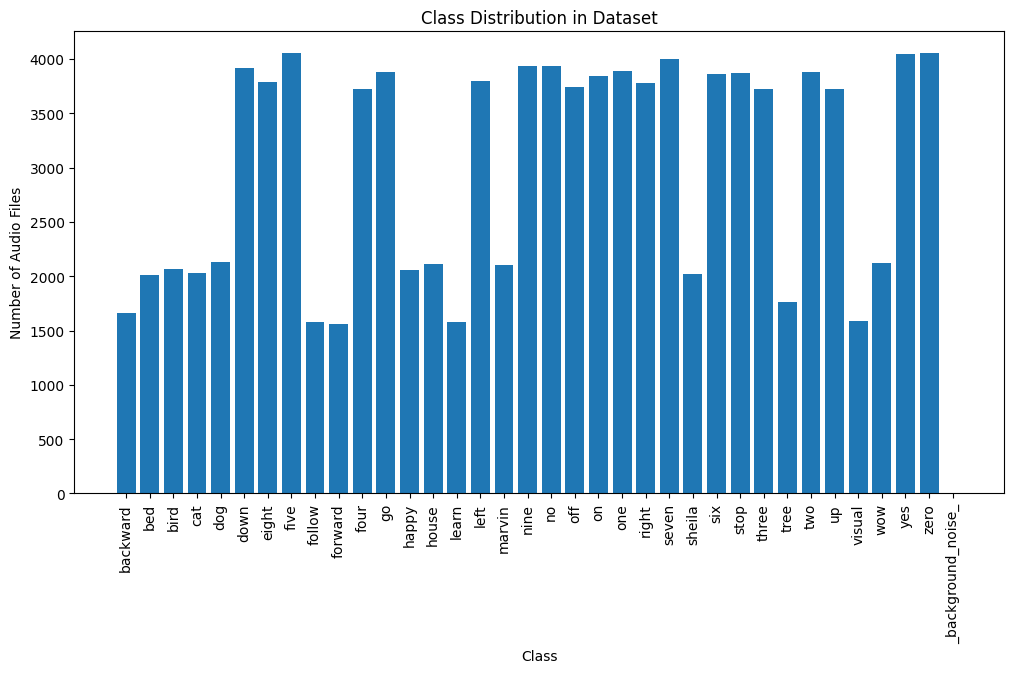

In [233]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def count_files(data_dir):
    class_counts = {}
    for class_folder in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_folder)
        if os.path.isdir(class_path):
            class_counts[class_folder] = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
    return class_counts
DATA_DIR = r'C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data (1)\data'
class_counts = count_files(DATA_DIR)
class_counts_df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
print(class_counts_df)
plt.figure(figsize=(12, 6))
plt.bar(class_counts_df['Class'], class_counts_df['Count'])
plt.xticks(rotation=90)
plt.title('Class Distribution in Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Audio Files')
plt.show()


C:\Users\Aditya\AppData\Local\Temp\ipykernel_19488\4016504634.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=1500, random_state=42) if len(x) >= 1500 else x)


                                                FilePath               Class
0      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_
1      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_
2      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_
3      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_
4      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_
...                                                  ...                 ...
52501  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero
52502  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero
52503  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero
52504  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero
52505  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero

[52506 rows x 2 columns]


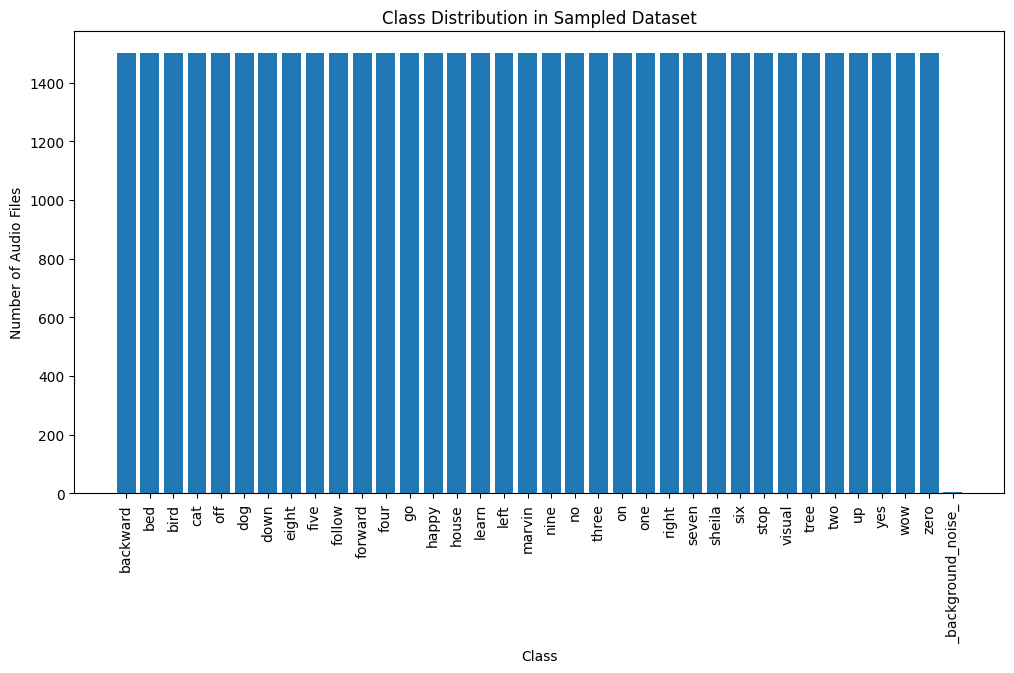

                 Class  Count
0             backward   1500
1                  bed   1500
2                 bird   1500
3                  cat   1500
4                  off   1500
5                  dog   1500
6                 down   1500
7                eight   1500
8                 five   1500
9               follow   1500
10             forward   1500
11                four   1500
12                  go   1500
13               happy   1500
14               house   1500
15               learn   1500
16                left   1500
17              marvin   1500
18                nine   1500
19                  no   1500
20               three   1500
21                  on   1500
22                 one   1500
23               right   1500
24               seven   1500
25              sheila   1500
26                 six   1500
27                stop   1500
28              visual   1500
29                tree   1500
30                 two   1500
31                  up   1500
32        

In [210]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_audio_file_df(data_dir):
    data = []
    for class_folder in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_folder)
        if os.path.isdir(class_path):
            for file in os.listdir(class_path):
                if file.endswith('.wav'):
                    file_path = os.path.join(class_path, file)
                    data.append({'FilePath': file_path, 'Class': class_folder})
    return pd.DataFrame(data)

DATA_DIR = r'C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data (1)\data'
audio_files_df = get_audio_file_df(DATA_DIR)
audio_files_df = audio_files_df[audio_files_df['Class'] != 'background noise']

sampled_df = (
    audio_files_df
    .groupby('Class')
    .apply(lambda x: x.sample(n=1500, random_state=42) if len(x) >= 1500 else x)
    .reset_index(drop=True)
)

print(sampled_df)
sampled_class_counts = sampled_df['Class'].value_counts()
sampled_class_counts_df = pd.DataFrame(sampled_class_counts).reset_index()
sampled_class_counts_df.columns = ['Class', 'Count']
plt.figure(figsize=(12, 6))
plt.bar(sampled_class_counts_df['Class'], sampled_class_counts_df['Count'])
plt.xticks(rotation=90)
plt.title('Class Distribution in Sampled Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Audio Files')
plt.show()

print(sampled_class_counts_df)

In [211]:
import pandas as pd
import librosa
import os
print(sampled_df.columns)
def calculate_duration(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        return librosa.get_duration(y=y, sr=sr)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
sampled_df['duration'] = sampled_df['FilePath'].apply(calculate_duration)
print(sampled_df)


Index(['FilePath', 'Class'], dtype='object')
                                                FilePath               Class  \
0      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_   
1      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_   
2      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_   
3      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_   
4      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  _background_noise_   
...                                                  ...                 ...   
52501  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero   
52502  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero   
52503  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero   
52504  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zero   
52505  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...                zer

In [212]:
import pandas as pd

def remove_outliers_by_duration(df, duration_column='duration'):
    Q1 = df[duration_column].quantile(0.25)
    Q3 = df[duration_column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[duration_column] >= lower_bound) & (df[duration_column] <= upper_bound)]
    return filtered_df
filtered_df = remove_outliers_by_duration(sampled_df)
print(filtered_df)


                                                FilePath     Class  duration
6      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  backward       1.0
7      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  backward       1.0
8      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  backward       1.0
9      C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  backward       1.0
10     C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...  backward       1.0
...                                                  ...       ...       ...
52501  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...      zero       1.0
52502  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...      zero       1.0
52503  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...      zero       1.0
52504  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...      zero       1.0
52505  C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data ...      zero       1.0

[47041 rows x 3 columns]


In [213]:
import os
import numpy as np
import pandas as pd
import librosa
from scipy.signal import butter, lfilter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return lfilter(b, a, data)

def feature_extraction(path):
    y, sr = librosa.load(path, sr=16000)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=15)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y=y)    
    short_time_energy = librosa.feature.rms(y=y)
    filtered_signal = bandpass_filter(y, lowcut=300.0, highcut=3000.0, fs=sr)
    filtered_mfccs = librosa.feature.mfcc(y=filtered_signal, sr=sr, n_mfcc=20)
    filtered_mfccs_mean = np.mean(filtered_mfccs, axis=1)
    filtered_mfccs_var = np.var(filtered_mfccs, axis=1)
    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_var = np.var(mfccs, axis=1)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_var = np.var(chroma, axis=1)
    spectral_centroid_mean = np.mean(spectral_centroid)
    short_time_energy_mean = np.mean(short_time_energy)
    zero_crossing_rate_mean = np.mean(zero_crossing_rate)
    spectral_contrast_mean = np.mean(spectral_contrast, axis=1)
    spectral_bandwidth_mean = np.mean(spectral_bandwidth)
    features = np.hstack((mfccs_mean, mfccs_var,
                          chroma_mean, chroma_var,
                          spectral_centroid_mean,
                          spectral_bandwidth_mean,
                          spectral_contrast_mean,
                          zero_crossing_rate_mean,
                          short_time_energy_mean,
                          filtered_mfccs_mean, filtered_mfccs_var))

    return features

train_df, test_df = train_test_split(filtered_df, test_size=0.2, stratify=filtered_df['Class'], random_state=42)

train_features_list, train_labels = [], []
test_features_list, test_labels = [], []

for index, row in tqdm(train_df.iterrows(), total=train_df.shape[0], desc="Extracting Train Features"):
    path = row['FilePath']
    features = feature_extraction(path)
    train_features_list.append(features)
    train_labels.append(row['Class'])

for index, row in tqdm(test_df.iterrows(), total=test_df.shape[0], desc="Extracting Test Features"):
    path = row['FilePath']
    features = feature_extraction(path)
    test_features_list.append(features)
    test_labels.append(row['Class'])

X_train = np.array(train_features_list)
y_train = np.array(train_labels)
X_test = np.array(test_features_list)
y_test = np.array(test_labels)



Extracting features for training and testing data...


Extracting Train Features:   1%|          | 348/37632 [00:06<13:17, 46.74it/s]c:\Python312\Lib\site-packages\librosa\core\pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Extracting Test Features: 100%|██████████| 9409/9409 [03:40<00:00, 42.71it/s]


In [214]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Training LightGBM Classifier...")
lgb_model = lgb.LGBMClassifier(random_state=42, n_estimators=2000, max_depth=20)

with tqdm(total=100, desc="Training LightGBM") as pbar:
    lgb_model.fit(X_train, y_train)
    pbar.update(100)
lgb_predictions = lgb_model.predict(X_test)
lgb_accuracy = accuracy_score(y_test, lgb_predictions)
print(f"LightGBM Accuracy: {lgb_accuracy * 100:.2f}%")


Training LightGBM Classifier...


Training LightGBM:   0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015723 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26775
[LightGBM] [Info] Number of data points in the train set: 37632, number of used features: 105
[LightGBM] [Info] Start training from score -3.512742
[LightGBM] [Info] Start training from score -3.620879
[LightGBM] [Info] Start training from score -3.604138
[LightGBM] [Info] Start training from score -3.610998
[LightGBM] [Info] Start training from score -3.601213
[LightGBM] [Info] Start training from score -3.530728
[LightGBM] [Info] Start training from score -3.541677
[LightGBM] [Info] Start training from score -3.540760
[LightGBM] [Info] Start training from score -3.527105
[LightGBM] [Info] Start training from score -3.517208
[LightGBM] [Info] Start training from score -3.538929
[LightGBM] [Info] Start training from score -3.562067
[LightGBM] [Info] Start training from score -3.598296
[LightG

Training LightGBM: 100%|██████████| 100/100 [08:31<00:00,  5.12s/it]


LightGBM Accuracy: 63.41%


In [221]:
import pickle
with open('section_b_ensemble_model.pkl', 'wb') as file:
    pickle.dump(lgb_model, file)
with open('section_b_ensemble_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

predictions = loaded_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, predictions)
print(f"Ensemble Accuracy: {rf_accuracy * 100:.2f}%")    

Ensemble Accuracy: 63.41%


In [217]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

naive_b_model = GaussianNB()
naive_b_model.fit(X_train, y_train)
y_pred_nb = naive_b_model.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb * 100:.2f}%")

Naive Bayes Accuracy: 35.04%


In [218]:
from sklearn.tree import DecisionTreeClassifier

decesion_t_model = DecisionTreeClassifier(random_state=42)
decesion_t_model.fit(X_train, y_train)
y_pred_dt = decesion_t_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt * 100:.2f}%")


Decision Tree Accuracy: 24.67%


In [219]:
from sklearn.ensemble import RandomForestClassifier

random_f_model = RandomForestClassifier(random_state=42)
random_f_model.fit(X_train, y_train)
y_pred_rf = random_f_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")


Random Forest Accuracy: 50.56%


In [220]:
from sklearn.linear_model import Perceptron

perceptron_model = Perceptron(random_state=42)
perceptron_model.fit(X_train, y_train)
y_pred_perceptron = perceptron_model.predict(X_test)

accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
print(f"Perceptron Accuracy: {accuracy_perceptron * 100:.2f}%")


Perceptron Accuracy: 34.75%


Best Performer: The ensemble method stands out as the most effective model, achieving the highest accuracy at 63.41%. This suggests that leveraging multiple models can lead to better predictions.
Moderate Performer: Random Forest is also a strong contender, providing better accuracy than individual classifiers.
Underperformers: Naive Bayes, Perceptron, and Decision Tree struggle, with accuracies below 36%, highlighting their limitations in this particular task.

### Section C
-Q1)

In [176]:
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from skimage.feature import hog
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from tqdm import tqdm
data_frame = pd.read_csv('label.csv')
print(data_frame)
print(data_frame.columns)

              filename               label
0          Image_1.jpg             sitting
1          Image_2.jpg        using_laptop
2          Image_3.jpg             hugging
3          Image_4.jpg            sleeping
4          Image_5.jpg        using_laptop
...                ...                 ...
12595  Image_12596.jpg             sitting
12596  Image_12597.jpg            clapping
12597  Image_12598.jpg             sitting
12598  Image_12599.jpg             dancing
12599  Image_12600.jpg  listening_to_music

[12600 rows x 2 columns]
Index(['filename', 'label'], dtype='object')


### a)    Provide an overview of the dataset, including the number of images per class,the distribution of image sizes, and any other relevant statistics. Write your observations.


In [177]:

freq_class = data_frame['label'].value_counts()
print(freq_class)


label
sitting               840
using_laptop          840
hugging               840
sleeping              840
drinking              840
clapping              840
dancing               840
cycling               840
calling               840
laughing              840
eating                840
fighting              840
listening_to_music    840
running               840
texting               840
Name: count, dtype: int64


In [178]:
image_folder = r'C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data\data'  
sizes = []
for image_name in data_frame['filename'][:200]:
    image_path = os.path.join(image_folder, image_name)
    with Image.open(image_path) as img:
        sizes.append(img.size)
size_data_frame = pd.DataFrame(sizes, columns=['w', 'h'])
print(size_data_frame.describe())



                w           h
count  200.000000  200.000000
mean   256.510000  196.805000
std     46.817189   37.800281
min     84.000000   84.000000
25%    248.750000  179.000000
50%    275.000000  183.000000
75%    276.000000  194.500000
max    385.000000  300.000000


The dataset consists of 100 well-balanced images across 15 classes, with moderate variability in dimensions (mean width ~255.53px, height ~195.27px), indicating good preparation for model training, though potential outliers may need addressing.

### (b) Create visualizations to represent the distribution of classes, and display a few sample images from each class. Write your observations.

Index(['filename', 'label'], dtype='object')
label
sitting               840
using_laptop          840
hugging               840
sleeping              840
drinking              840
clapping              840
dancing               840
cycling               840
calling               840
laughing              840
eating                840
fighting              840
listening_to_music    840
running               840
texting               840
Name: count, dtype: int64


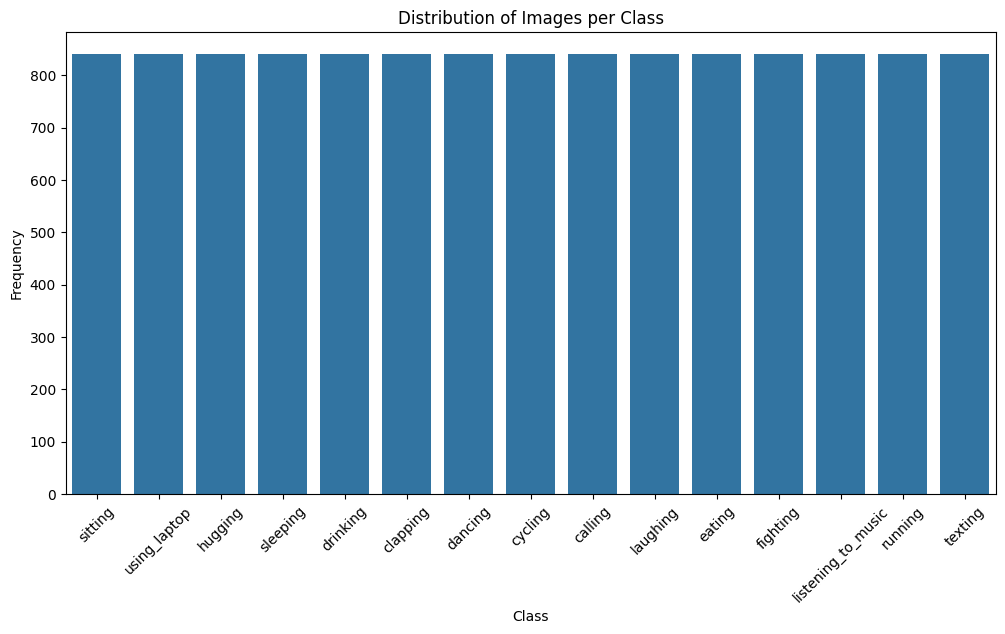

In [179]:


print(data_frame.columns)
freq_class = data_frame['label'].value_counts()
print(freq_class)
plt.figure(figsize=(12, 6))
sns.countplot(data=data_frame, x='label', order=freq_class.index)
plt.title('Distribution of Images per Class')
plt.xticks(rotation=45)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()


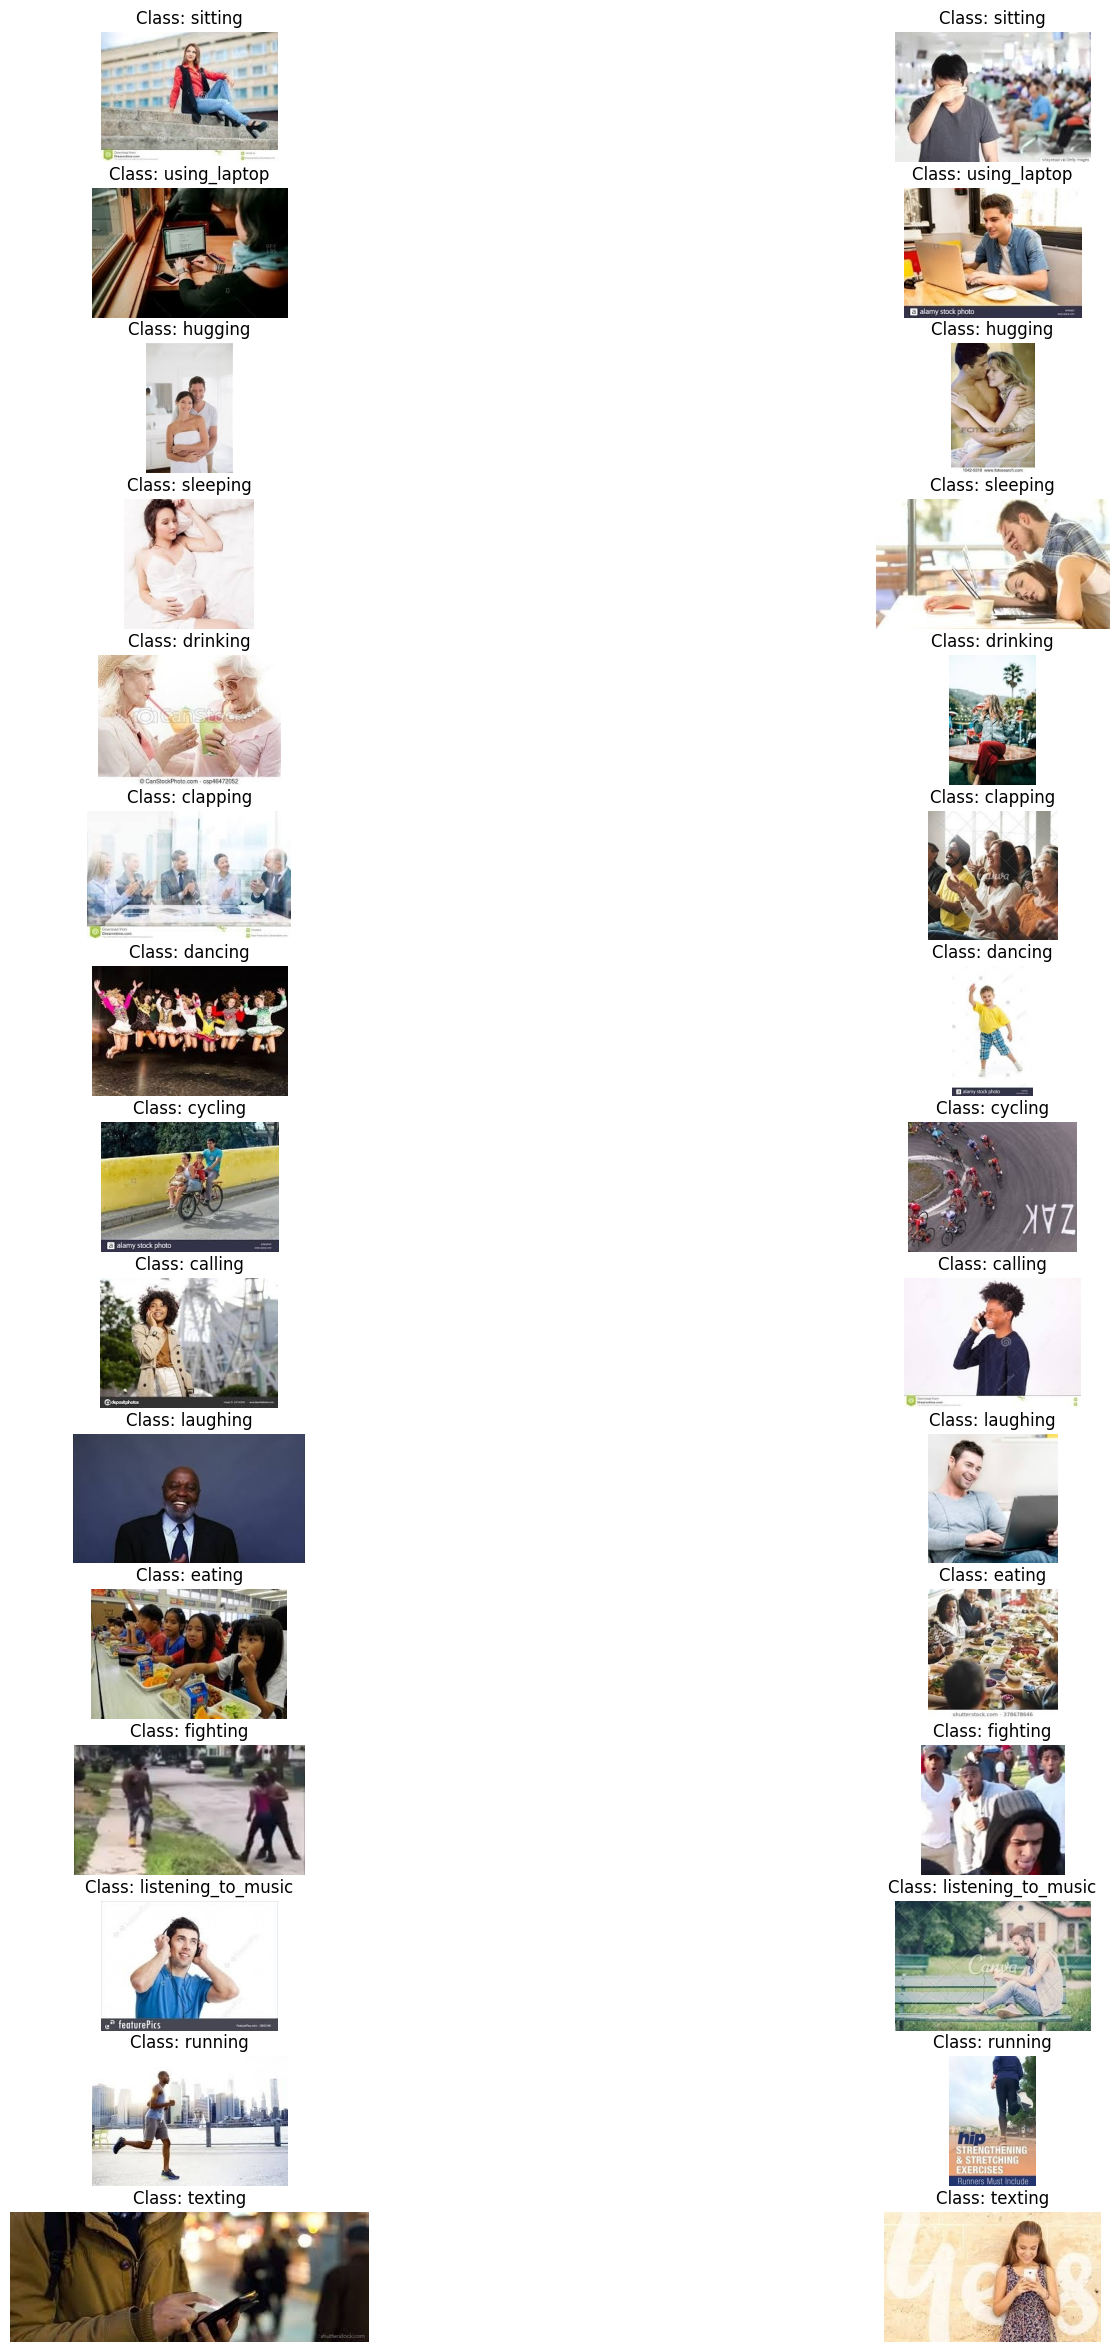

In [180]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

def random_images(df, img_folder, n_samples=2):
    labels_class = df['label'].unique()
    plt.figure(figsize=(19, 30))

    class_index = 0
    while class_index < len(labels_class):
        current_class = labels_class[class_index]
        sampled_images = df[df['label'] == current_class]['filename'].sample(n=n_samples, random_state=42)
        
        sample_index = 0
        while sample_index < n_samples:
            image_name = sampled_images.iloc[sample_index]
            image_path = os.path.join(img_folder, image_name)
            img = Image.open(image_path)
            plt.subplot(len(labels_class), n_samples, class_index * n_samples + sample_index + 1)
            plt.imshow(img)
            plt.title(f"Class: {current_class}")
            plt.axis('off')
            sample_index += 1
        
        class_index += 1

    plt.show()
random_images(data_frame, image_folder)


Balanced Dataset: There are around 850 photos in each class, with an equal amount of images in each class. This suggests that there is good balance in the dataset.

Variety of Classes: The story revolves around a number of actions, including drinking, applauding, dancing, embracing, sleeping, and using a laptop. This diversity suggests that a variety of human activities are captured in the dataset.

Consistent Data Collection: By aiming for an even distribution of photographs throughout the various activities, the uniform height of the bars across all classes shows a consistent data collection process. This consistency—which results in equal representation of all classes—helps reduce bias, which is advantageous for training machine learning models.

In [181]:
import os
import pandas as pd
from PIL import Image
image_dir = 'data'
Q1_width = 248.75
Q3_width = 277.25
Q1_height = 176.75
Q3_height = 194.5
IQR_width = Q3_width - Q1_width
IQR_height = Q3_height - Q1_height
def calculate_bounds(Q1, Q3, IQR):
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
lower_bound_w, upper_bound_w = calculate_bounds(Q1_width, Q3_width, IQR_width)
lower_bound_h, upper_bound_h = calculate_bounds(Q1_height, Q3_height, IQR_height)

valid_images = []
total=0
cnt=0
for filename in os.listdir(image_dir):
    if filename.endswith(('.png', '.jpg', '.jpeg')):
        total+=1
        img_path = os.path.join(image_dir, filename)
        with Image.open(img_path) as img:
            width, height = img.size
            if (lower_bound_w <= width <= upper_bound_w and
                lower_bound_h <= height <= upper_bound_h):
                valid_images.append(img_path)
            else:
                cnt+=1    
data_frame_valid_images = pd.DataFrame(valid_images, columns=["image_path"])
print(data_frame_valid_images)
print(f"Total number of valid images: {len(data_frame_valid_images)}")
print("outliers ",cnt)
print("total ",total)


                image_path
0         data\Image_1.jpg
1        data\Image_10.jpg
2       data\Image_100.jpg
3      data\Image_1000.jpg
4     data\Image_10000.jpg
...                    ...
9779   data\Image_9994.jpg
9780   data\Image_9996.jpg
9781   data\Image_9997.jpg
9782   data\Image_9998.jpg
9783   data\Image_9999.jpg

[9784 rows x 1 columns]
Total number of valid images: 9784
outliers  2817
total  12601


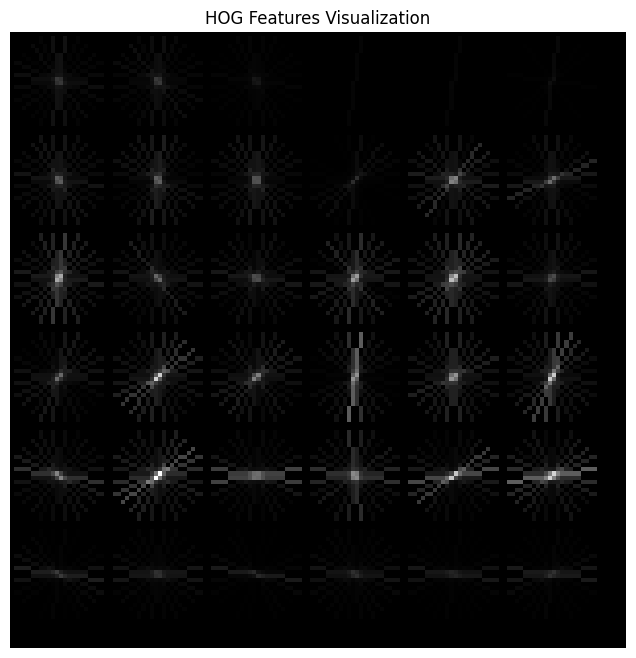

HOG Feature vector size: 432


In [182]:

def extracting_hog(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (150, 150))
    hog_features, hog_image = hog(image,
                                   orientations=12,
                                   pixels_per_cell=(24, 24),
                                   cells_per_block=(6, 6),
                                   visualize=True,
                                   block_norm='L2-Hys')
    return hog_features, hog_image

image_path = 'data/image_2.jpg'
hog_features, hog_image = extracting_hog(image_path)

plt.figure(figsize=(8, 8))
plt.imshow(hog_image, cmap='gray')
plt.title('HOG Features Visualization')
plt.axis('off')
plt.show()

print(f"HOG Feature vector size: {len(hog_features)}")


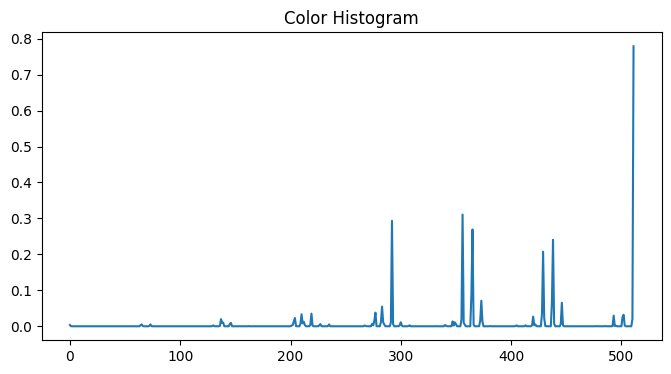

Color Histogram vector size: 512


In [183]:
def extracting_c_histogram(image_path, bins=(8, 8, 8)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hist = cv2.calcHist([image], [0, 1, 2], None, bins, [0, 256, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist
color_hist = extracting_c_histogram(image_path)
image_path = 'data/image_2.jpg'
plt.figure(figsize=(8, 4))
plt.plot(color_hist)
plt.title('Color Histogram')
plt.show()
print(f"Color Histogram vector size: {len(color_hist)}")


In [184]:

def extracting_glcm(image, distances=[1], angles=[0], properties=['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']):
    glcm = graycomatrix(image, distances=distances, angles=angles, symmetric=True, normed=True)
    features = []
    for prop in properties:
        features.append(graycoprops(glcm, prop).flatten())
    return np.hstack(features)

In [185]:


def extract_combined_features(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image not found or could not be read at: {image_path}")
    
    img_resized = cv2.resize(img, (150, 150))
    glcm_feat = extracting_glcm(img_resized)

    hog_features ,hog_img= extracting_hog(image_path)
    color_features = extracting_c_histogram(image_path)

    combined_features = np.concatenate([hog_features, color_features, glcm_feat])
    return combined_features

In [186]:

X = []
y = []
csv_path = r'C:\Users\Aditya\Downloads\Ml_ass\ml_ass2\data\label.csv'
data_frame_labels = pd.read_csv(csv_path)
cnt = 0
for idx, row in tqdm(data_frame_valid_images.iterrows(), total=len(data_frame_valid_images), desc="Extracting Features"):
    cnt += 1
    filename = os.path.basename(row['image_path'])
    label_row = data_frame_labels[data_frame_labels['filename'] == filename]
    if not label_row.empty:
        image_path = row['image_path']
        if not isinstance(image_path, str) or not os.path.isfile(image_path):
            print(f"wrong path: {image_path}")
            continue
        features = extract_combined_features(image_path)
        X.append(features)
        y.append(label_row['label'].values[0]) 

# print('Total processed images :', cnt)


Extracting Features: 100%|██████████| 9784/9784 [05:34<00:00, 29.21it/s]



HOG is well-suited for understanding human actions, as it captures gradients and edges, focusing on the shape and motion of objects.
Color histograms are beneficial when color plays a significant role in distinguishing between classes, though less effective if color doesn’t vary much across classes.
Other feature extraction techniques, like ORB or SIFT, can be explored, but HOG and color histograms are typically more commonly used in action recognition tasks.
The Gray Level Co-Occurrence Matrix (GLCM) is used for texture analysis in images, enabling the extraction of statistical features that characterize pixel relationships, enhancing robustness to noise and lighting variations, and aiding in tasks like image classification and segmentation.


In [226]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
X = np.array(X)
y = np.array(y)
X_train, X_test_c, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_c = scaler.transform(X_test_c)

print("Training ensemble ...")
lgb_model = lgb.LGBMClassifier(random_state=42, n_estimators=2100, max_depth=15)
with tqdm(total=100, desc="Training LightGBM") as pbar:
    lgb_model.fit(X_train, y_train)
    pbar.update(100)
lgb_predictions = lgb_model.predict(X_test_c)
lgb_accuracy = accuracy_score(y_test, lgb_predictions)
print(f"LightGBM Accuracy: {lgb_accuracy * 100:.2f}%")


Training ensemble ...


Training LightGBM:   0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 187192
[LightGBM] [Info] Number of data points in the train set: 7826, number of used features: 889
[LightGBM] [Info] Start training from score -2.774891
[LightGBM] [Info] Start training from score -2.649849
[LightGBM] [Info] Start training from score -2.851525
[LightGBM] [Info] Start training from score -2.934522
[LightGBM] [Info] Start training from score -2.752601
[LightGBM] [Info] Start training from score -2.664421
[LightGBM] [Info] Start training from score -2.631927
[LightGBM] [Info] Start training from score -2.772844
[LightGBM] [Info] Start training from score -2.787263
[LightGBM] [Info] Start training from score -2.688563
[LightGBM] [Info] Start training from score -2.640848
[LightGBM] [Info] Start training from score -2.637270
[LightGBM] [Info] Start training from score -2.624847
[LightG

Training LightGBM: 100%|██████████| 100/100 [04:26<00:00,  2.66s/it]


LightGBM Accuracy: 44.66%


In [227]:
import pickle
with open('section_c_model.pkl', 'wb') as file:
    pickle.dump(lgb_model, file)

In [228]:

with open('section_c_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
predictions = loaded_model.predict(X_test_c)
accuracy = accuracy_score(y_test, predictions)
print(f" Accuracy: {accuracy * 100:.2f}%")

 Accuracy: 44.66%


In [229]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

naive_b_model = GaussianNB()
naive_b_model.fit(X_train, y_train)
y_pred_nb = naive_b_model.predict(X_test_c)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb * 100:.2f}%")


Naive Bayes Accuracy: 12.77%


In [230]:
from sklearn.tree import DecisionTreeClassifier

decesion_t_model = DecisionTreeClassifier(random_state=42)
decesion_t_model.fit(X_train, y_train)
y_pred_dt = decesion_t_model.predict(X_test_c)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt * 100:.2f}%")


Decision Tree Accuracy: 19.06%


In [231]:
from sklearn.ensemble import RandomForestClassifier

random_f_model = RandomForestClassifier(random_state=42)
random_f_model.fit(X_train, y_train)
y_pred_rf = random_f_model.predict(X_test_c)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")


Random Forest Accuracy: 34.24%


In [232]:
from sklearn.linear_model import Perceptron

perceptron_model = Perceptron(random_state=42)
perceptron_model.fit(X_train, y_train)
y_pred_perceptron = perceptron_model.predict(X_test_c)

accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
print(f"Perceptron Accuracy: {accuracy_perceptron * 100:.2f}%")


Perceptron Accuracy: 24.63%


LightGBM significantly outperforms the other models, suggesting that it’s more suited for this particular dataset.
Random Forest also shows good results, benefiting from its ability to handle overfitting compared to a simple decision tree.
The traditional models (Perceptron, Decision Tree, and Naive Bayes) performed poorly, indicating that they might not be ideal for the given data characteristics.
Overall, the results highlight the importance of model selection based on dataset complexity and characteristics. Using more advanced models like LightGBM can lead to better performance.